# Solar Radiation — Verification & Visualization

**Purpose:** sanity-check the PVGIS hourly solar pull (`solar_radiation/pull_pvgis.py`) for the
facility fleet before it feeds the flatblock optimization.

Each facility has a 2023 hourly PV yield profile (`P_kWperkWp`, kWh per installed kWp) from
PVGIS-ERA5, tilt = latitude, optimal azimuth, 0 % system loss. We verify:

1. **Completeness** — every facility has a full 8760-hour profile; flag empties.
2. **Magnitude** — annual yields sit in the physically expected EU range (~900–2000 kWh/kWp).
3. **Latitude gradient** — yield falls with latitude (the dominant physical driver).
4. **Geography** — the spatial pattern matches known European solar resource.
5. **National averages** — country means line up with published PVGIS figures.
6. **Temporal shape** — diurnal and seasonal profiles have the right form (midday peak, summer peak).


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# --- paths -----------------------------------------------------------------
ROOT = Path.cwd()
while not (ROOT / "solar_radiation").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SOLAR = ROOT / "solar_radiation" / "outputs"
SUMMARY = SOLAR / "solar_radiation_by_facility.csv"
HOURLY = SOLAR / "hourly_profiles"

# --- house style (dataviz principles: recessive axes, thin marks) ----------
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.8,
    "axes.edgecolor": "#888888", "axes.linewidth": 0.8,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "axes.labelcolor": "#222222", "text.color": "#222222",
})
# Sequential (magnitude) = perceptually-uniform, colorblind-safe.
SEQ = "cividis"
# Categorical = Okabe-Ito colorblind-safe set, assigned in fixed order.
OKABE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#F0E442"]
INK, MUTED = "#222222", "#666666"

summary = pd.read_csv(SUMMARY)
print(f"Summary rows: {len(summary):,}   countries: {summary['iso3_country'].nunique()}")
summary.head()


Summary rows: 2,199   countries: 27


,source_id,source_name,iso3_country,lat,lon,year,annual_yield_kwh_per_kwp,capacity_factor,pvgis_raddatabase,tilt_deg,azimuth_deg,system_loss_pct
0,38480620,Agrana Zucker Gmbh,AUT,48.32,16.04,2023,"1,375.71",0.16,PVGIS-ERA5,48.32,0,0.00
1,38480613,Agrana Zucker Gmbh,AUT,48.24,16.70,2023,"1,390.66",0.16,PVGIS-ERA5,48.24,0,0.00
2,32267416,Austria,AUT,47.61,14.08,2023,"1,381.87",0.16,PVGIS-ERA5,47.61,0,0.00
3,38480528,Bunge Austria Gmbh,AUT,48.02,16.75,2023,"1,387.47",0.16,PVGIS-ERA5,48.02,0,0.00
4,38479269,Eibetex,AUT,48.82,15.28,2023,"1,353.03",0.15,PVGIS-ERA5,48.82,0,0.00


## 1. Completeness & data quality

Confirm the summary row count matches the parquet profiles, every profile is a full 8760-hour year, and flag any facility with a zero / near-zero annual yield (a PVGIS response that parsed empty and was silently zero-filled).

In [2]:
profile_files = sorted(HOURLY.glob("*_2023.parquet"))
profile_ids = {int(p.stem.split("_")[0]) for p in profile_files}
summary_ids = set(summary["source_id"])

print(f"parquet profiles      : {len(profile_files):,}")
print(f"summary rows          : {len(summary):,}")
print(f"ids in summary only   : {len(summary_ids - profile_ids)}")
print(f"ids in profiles only  : {len(profile_ids - summary_ids)}")

# Zero / suspiciously low annual yield
LOW = 600  # kWh/kWp — below any real European site
flagged = summary[summary["annual_yield_kwh_per_kwp"] < LOW].sort_values("annual_yield_kwh_per_kwp")
print(f"\nFacilities with annual yield < {LOW} kWh/kWp: {len(flagged)}")
flagged[["source_id", "source_name", "iso3_country", "lat", "lon", "annual_yield_kwh_per_kwp"]]


parquet profiles      : 2,199
summary rows          : 2,199
ids in summary only   : 0
ids in profiles only  : 0

Facilities with annual yield < 600 kWh/kWp: 0


,source_id,source_name,iso3_country,lat,lon,annual_yield_kwh_per_kwp


In [3]:
# Verify a full 8760-hour, correctly-ordered profile on a canonical index.
CANON = pd.date_range("2023-01-01 00:00", "2023-12-31 23:00", freq="h")  # 8760, non-leap
assert len(CANON) == 8760

bad_len, checked = [], 0
for p in profile_files:
    n = len(pd.read_parquet(p, columns=["P_kWperkWp"]))
    checked += 1
    if n != 8760:
        bad_len.append((p.stem, n))
print(f"profiles checked: {checked:,}")
print(f"profiles NOT 8760 hours: {len(bad_len)}")
if bad_len:
    print(bad_len[:10])


profiles checked: 2,199
profiles NOT 8760 hours: 0


## 2. Annual yield distribution

European PV yields for well-sited, optimally-tilted systems run roughly **900–2000 kWh/kWp** (north to south). The bulk of the fleet should sit inside that band.

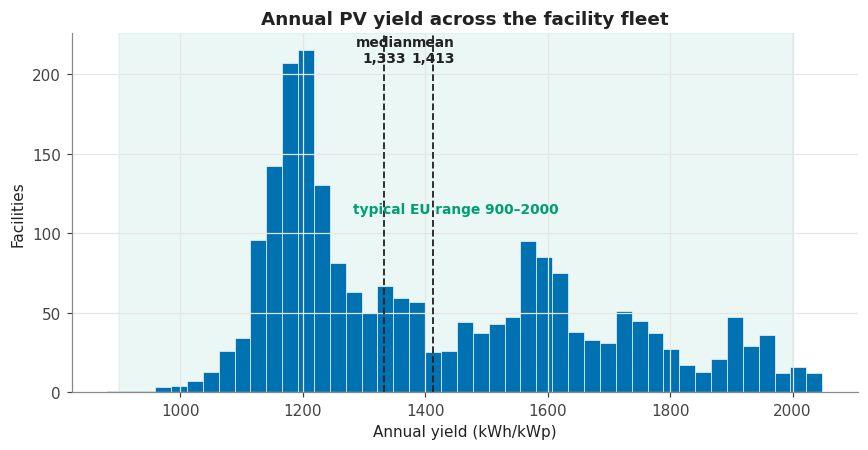

count   2,199.00
mean    1,413.08
std       259.06
min       880.86
25%     1,193.94
50%     1,332.98
75%     1,606.74
max     2,048.56


In [4]:
y = summary.loc[summary["annual_yield_kwh_per_kwp"] > 0, "annual_yield_kwh_per_kwp"]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(y, bins=45, color="#0072B2", edgecolor="white", linewidth=0.4)
ax.axvspan(900, 2000, color="#009E73", alpha=0.08, zorder=0)
for v, lab in [(y.median(), "median"), (y.mean(), "mean")]:
    ax.axvline(v, color=INK, ls="--", lw=1.2)
    ax.annotate(f"{lab}\n{v:,.0f}", (v, ax.get_ylim()[1]*0.92), ha="center",
                fontsize=9, color=INK, fontweight="bold")
ax.set_xlabel("Annual yield (kWh/kWp)"); ax.set_ylabel("Facilities")
ax.set_title("Annual PV yield across the facility fleet")
ax.annotate("typical EU range 900–2000", (1450, ax.get_ylim()[1]*0.5),
            ha="center", color="#009E73", fontsize=9, fontweight="bold")
plt.tight_layout(); plt.show()

print(summary["annual_yield_kwh_per_kwp"].describe().to_string())


## 3. Yield vs latitude — the key physical check

Annual insolation is driven first and foremost by latitude. A clean **negative** relationship (with scatter from local climate/cloud cover) is the strongest single signal that the pull is physically correct.

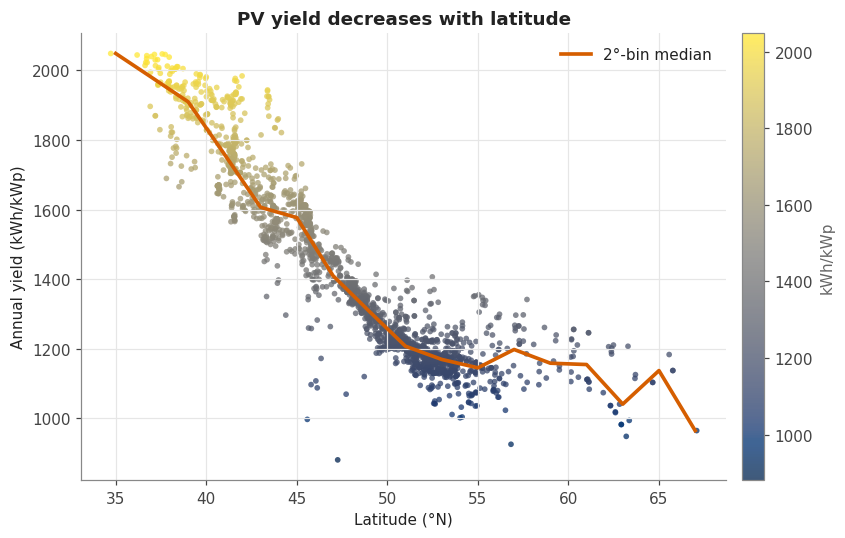

Pearson corr(latitude, annual yield) = -0.918  (expect strongly negative)


In [5]:
d = summary[summary["annual_yield_kwh_per_kwp"] > 0]

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(d["lat"], d["annual_yield_kwh_per_kwp"], c=d["annual_yield_kwh_per_kwp"],
                cmap=SEQ, s=14, alpha=0.75, edgecolor="none")
# LOESS-free trend: rolling median over latitude bins
bins = np.arange(np.floor(d["lat"].min()), np.ceil(d["lat"].max()) + 1, 2)
cent = (bins[:-1] + bins[1:]) / 2
med = [d.loc[(d["lat"] >= a) & (d["lat"] < b), "annual_yield_kwh_per_kwp"].median()
       for a, b in zip(bins[:-1], bins[1:])]
ax.plot(cent, med, color="#D55E00", lw=2.4, label="2°-bin median")
ax.set_xlabel("Latitude (°N)"); ax.set_ylabel("Annual yield (kWh/kWp)")
ax.set_title("PV yield decreases with latitude")
ax.legend(frameon=False, loc="upper right")
cb = fig.colorbar(sc, ax=ax, pad=0.02); cb.set_label("kWh/kWp", color=MUTED)
plt.tight_layout(); plt.show()

corr = d["lat"].corr(d["annual_yield_kwh_per_kwp"])
print(f"Pearson corr(latitude, annual yield) = {corr:.3f}  (expect strongly negative)")


## 4. Geographic pattern

Plotting each facility at its coordinates, colored by yield, should reproduce the familiar European solar map: bright Iberia / Italy / Greece, dark Nordics / UK / Baltics.

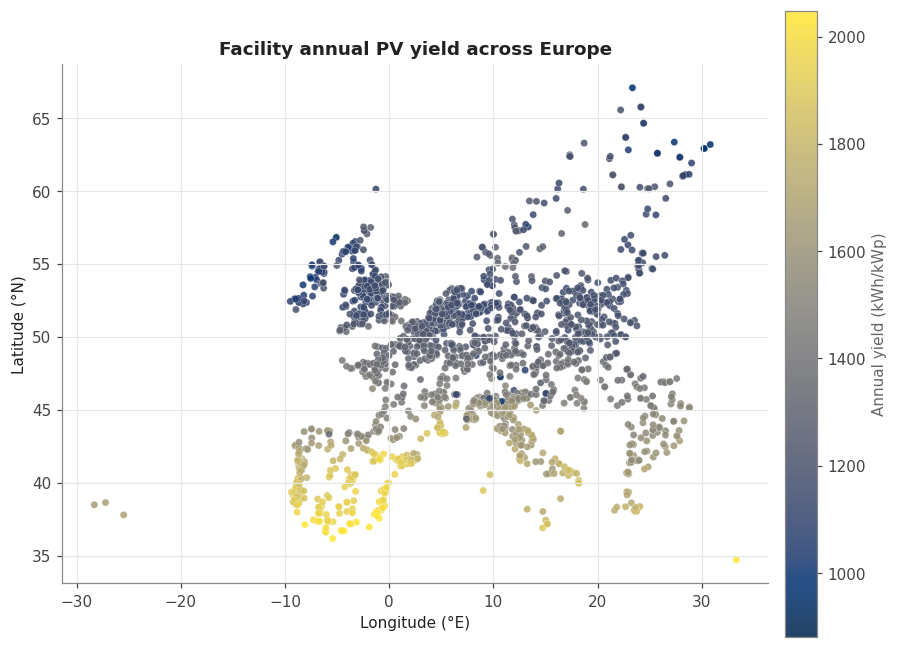

In [6]:
d = summary[summary["annual_yield_kwh_per_kwp"] > 0]

fig, ax = plt.subplots(figsize=(8.5, 7))
sc = ax.scatter(d["lon"], d["lat"], c=d["annual_yield_kwh_per_kwp"], cmap=SEQ,
                s=22, alpha=0.85, edgecolor="white", linewidth=0.2)
ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.set_title("Facility annual PV yield across Europe")
ax.set_aspect(1.4)
cb = fig.colorbar(sc, ax=ax, pad=0.02, shrink=0.85); cb.set_label("Annual yield (kWh/kWp)", color=MUTED)
plt.tight_layout(); plt.show()


## 5. National averages vs published PVGIS figures

Country-mean yields should track well-known national ballparks (optimally-tilted, PVGIS-class): Spain/Portugal ~1600–1800, Italy/Greece ~1500–1700, France ~1200–1400, Germany/Poland ~1050–1200, Nordics/UK ~900–1050 kWh/kWp.

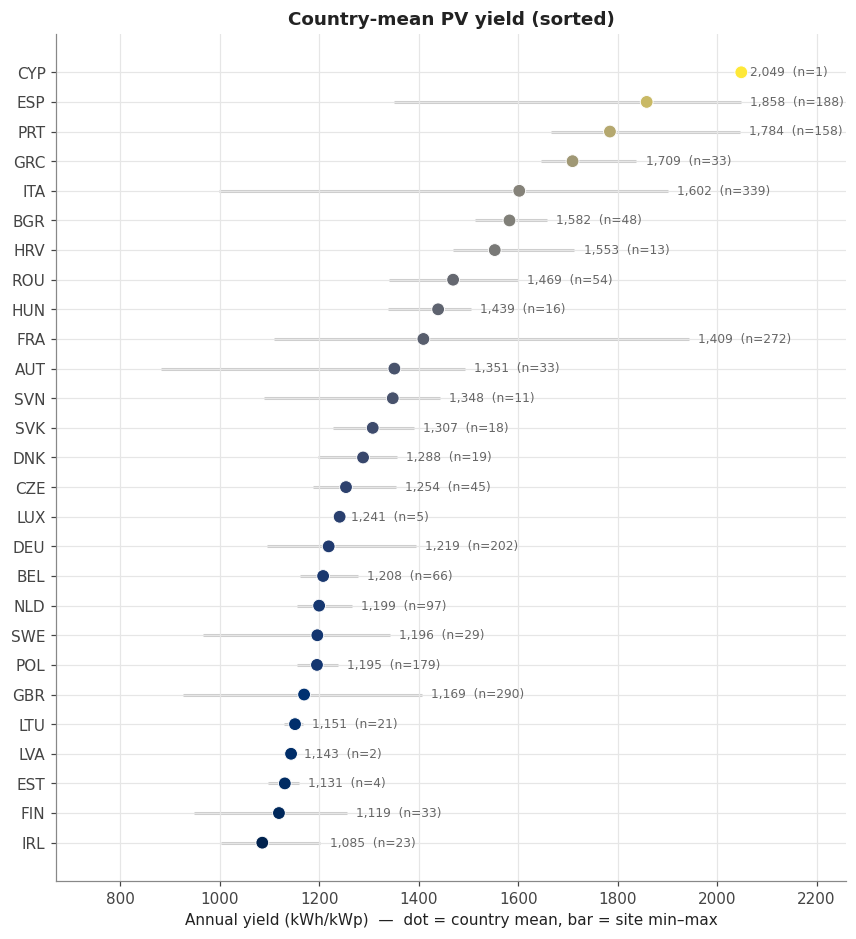

,count,mean,min,max
iso3_country,,,,
CYP,1,"2,049.00","2,049.00","2,049.00"
ESP,188,"1,858.00","1,350.00","2,047.00"
PRT,158,"1,784.00","1,666.00","2,046.00"
GRC,33,"1,709.00","1,646.00","1,838.00"
ITA,339,"1,602.00",997.00,"1,900.00"
BGR,48,"1,582.00","1,513.00","1,658.00"
HRV,13,"1,553.00","1,469.00","1,713.00"
ROU,54,"1,469.00","1,341.00","1,599.00"
HUN,16,"1,439.00","1,339.00","1,505.00"


In [7]:
by_country = (summary[summary["annual_yield_kwh_per_kwp"] > 0]
              .groupby("iso3_country")["annual_yield_kwh_per_kwp"]
              .agg(["count", "mean", "min", "max"]).sort_values("mean", ascending=False))

fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(by_country))))
ypos = np.arange(len(by_country))[::-1]
ax.hlines(ypos, by_country["min"], by_country["max"], color="#CCCCCC", lw=2, zorder=1)
sc = ax.scatter(by_country["mean"], ypos, c=by_country["mean"], cmap=SEQ, s=70,
                edgecolor="white", linewidth=0.6, zorder=2)
ax.set_yticks(ypos); ax.set_yticklabels(by_country.index)
ax.set_xlabel("Annual yield (kWh/kWp)  —  dot = country mean, bar = site min–max")
ax.set_title("Country-mean PV yield (sorted)")
for yv, (c, r) in zip(ypos, by_country.iterrows()):
    ax.annotate(f"{r['mean']:,.0f}  (n={int(r['count'])})", (r["max"], yv),
                xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=8, color=MUTED)
ax.margins(x=0.18)
plt.tight_layout(); plt.show()
by_country.round(0)


## 6. Temporal shape — diurnal & seasonal profiles

For a southern, a mid-latitude, and a northern facility we check the *shape* of generation: zero at night, a midday peak, and summer output well above winter. These come from the actual hourly parquet files.

In [8]:
# Pick representative non-zero facilities at low / median / high latitude.
d = summary[summary["annual_yield_kwh_per_kwp"] > 0].sort_values("lat").reset_index(drop=True)
picks = {
    "South": d.iloc[0],
    "Mid":   d.iloc[len(d) // 2],
    "North": d.iloc[-1],
}
for k, r in picks.items():
    print(f"{k:5s}  {r['source_name'][:32]:32s}  {r['iso3_country']}  "
          f"lat={r['lat']:.1f}  yield={r['annual_yield_kwh_per_kwp']:,.0f}")

def load_profile(sid):
    p = pd.read_parquet(HOURLY / f"{int(sid)}_2023.parquet", columns=["timestamp", "P_kWperkWp"])
    p["timestamp"] = pd.to_datetime(p["timestamp"])
    p["month"] = p["timestamp"].dt.month
    p["hour"] = p["timestamp"].dt.hour
    return p

profiles = {k: load_profile(r["source_id"]) for k, r in picks.items()}


South  Vassiliko Cement Plant            CYP  lat=34.7  yield=2,049
Mid    Fours À Chaux De Sorcy            FRA  lat=48.7  yield=1,326
North  Keroleather Ab                    SWE  lat=67.1  yield=965


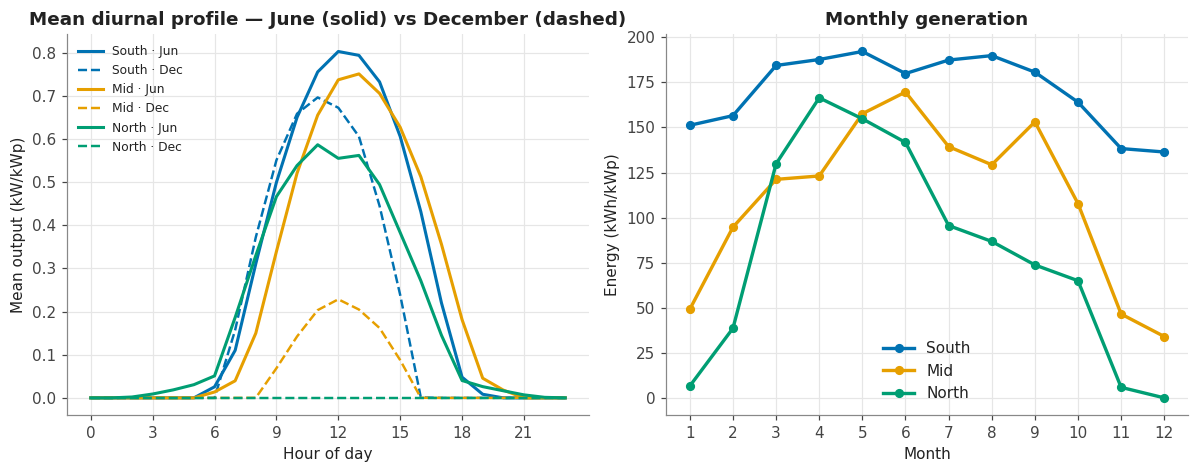

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

# (a) mean diurnal shape: summer (Jun) vs winter (Dec)
for (k, p), col in zip(profiles.items(), OKABE):
    jun = p[p["month"] == 6].groupby("hour")["P_kWperkWp"].mean()
    dec = p[p["month"] == 12].groupby("hour")["P_kWperkWp"].mean()
    axes[0].plot(jun.index, jun.values, color=col, lw=2, label=f"{k} · Jun")
    axes[0].plot(dec.index, dec.values, color=col, lw=1.6, ls="--", label=f"{k} · Dec")
axes[0].set_xlabel("Hour of day"); axes[0].set_ylabel("Mean output (kW/kWp)")
axes[0].set_title("Mean diurnal profile — June (solid) vs December (dashed)")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend(frameon=False, fontsize=8, ncol=1, loc="upper left")

# (b) monthly energy totals
for (k, p), col in zip(profiles.items(), OKABE):
    monthly = p.groupby("month")["P_kWperkWp"].sum()
    axes[1].plot(monthly.index, monthly.values, color=col, lw=2.2, marker="o", ms=5, label=k)
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Energy (kWh/kWp)")
axes[1].set_title("Monthly generation")
axes[1].set_xticks(range(1, 13))
axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()


### Fleet-wide seasonal–diurnal envelope

Accumulating the mean hourly output across **all** facilities (their profiles share an identical 8760-hour index) gives an hour-of-day × month heatmap — it should show a bright summer-midday core tapering to dark winter nights.

averaged 2,199 facility profiles


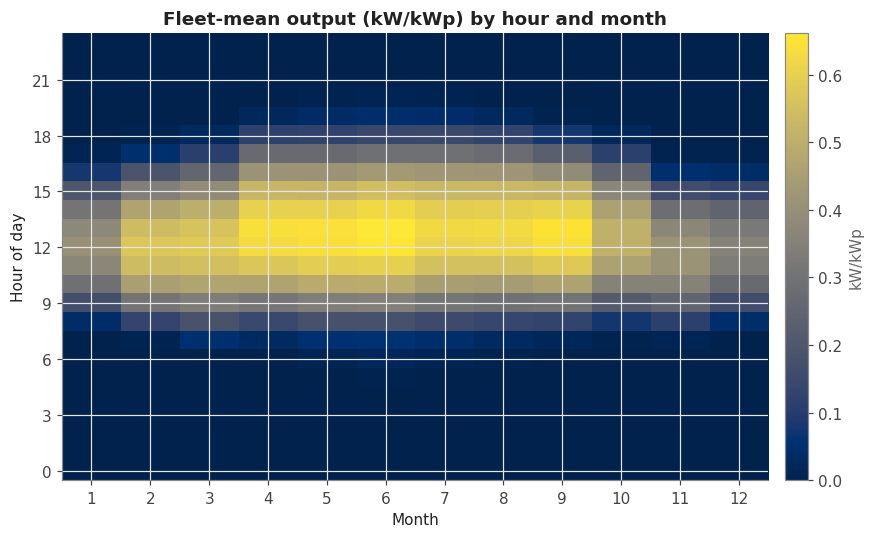

Fleet mean annual yield: 1,413 kWh/kWp
Fleet mean capacity factor: 0.161


In [10]:
# Incremental fleet mean over the canonical 8760-hour index (memory-light).
fleet_sum = np.zeros(8760)
n_ok = 0
for p in profile_files:
    v = pd.read_parquet(p, columns=["P_kWperkWp"])["P_kWperkWp"].to_numpy()
    if len(v) == 8760:
        fleet_sum += v
        n_ok += 1
fleet_mean = fleet_sum / n_ok
print(f"averaged {n_ok:,} facility profiles")

env = pd.DataFrame({"P": fleet_mean, "month": CANON.month, "hour": CANON.hour})
grid = env.pivot_table(index="hour", values="P", columns="month", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(grid.values, aspect="auto", cmap=SEQ, origin="lower",
               extent=[0.5, 12.5, -0.5, 23.5])
ax.set_xlabel("Month"); ax.set_ylabel("Hour of day")
ax.set_title("Fleet-mean output (kW/kWp) by hour and month")
ax.set_xticks(range(1, 13)); ax.set_yticks(range(0, 24, 3))
cb = fig.colorbar(im, ax=ax, pad=0.02); cb.set_label("kW/kWp", color=MUTED)
plt.tight_layout(); plt.show()

# Fleet capacity factor from the aggregate
print(f"Fleet mean annual yield: {fleet_mean.sum():,.0f} kWh/kWp")
print(f"Fleet mean capacity factor: {fleet_mean.mean():.3f}")


## 7. Verification summary

Fill in after running:

- **Completeness** — profiles vs summary rows match; all profiles are 8760 hours.
- **Zero-yield facilities** — the flagged GBR sites (§1) returned empty PVGIS responses and
  were zero-filled; they should be **re-pulled** (`pull_pvgis.py --overwrite` for those ids)
  or dropped before optimization.
- **Magnitude** — median/mean yield inside the 900–2000 kWh/kWp EU band.
- **Latitude gradient** — strong negative correlation (§3).
- **Geography** — southern Europe bright, north dark (§4).
- **National means** — consistent with published PVGIS figures (§5).
- **Temporal shape** — midday-peaked diurnal, summer-peaked seasonal, correct night zeros (§6).
